# Part 2 — Face Morphing-Attack Detection (D-MorphNet)
**Implementation of the reference paper:** *“DMorphNet: Face Morphing Detection Using Generative
Adversarial Networks and EfficientNet-B6”* (Gawade et al., COMPUTATIA 2026).

The paper's hybrid design is reproduced end-to-end on the dataset generated in **Part 1**:

| Paper component (§) | This notebook |
|---|---|
| §3.2 CLAHE + resize 528×528 + augmentation (JPEG, blur, noise, brightness/contrast, flips) | Sections 2–3 |
| §3.4 EfficientNet-B6 (ImageNet, top removed, **Global Average Pooling** → 2304-d features) | Section 4 |
| transfer-learning stage (trainable head, frozen backbone) → training curves | Section 6 |
| §3.5 SVM (RBF) on deep features, hinge-loss margin classifier | Section 7 |
| §4.1 confusion matrix, accuracy / precision / recall / F1 | Section 8 |
| §4.3 ROC curve + AUC | Section 8 |
| §4.4 threshold optimization on a validation set | Section 9 |
| §4.2 comparison of EfficientNet-B0 / B5 / B6 | Section 10 |
| §4.5 real-time prediction on new images | Section 11 |

The step-by-step SDLC engineering report is in `reports/Part2_SDLC_Report.md`.

In [1]:
import os, gc, time, json, random
from pathlib import Path
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc,
                             precision_recall_curve)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATASET, RESULTS = ROOT/'data'/'dataset', ROOT/'results'
RESULTS.mkdir(exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

C_BLUE, C_ORANGE, C_GREEN, C_MAGENTA, C_RED = '#2a78d6', '#eb6834', '#008300', '#e87ba4', '#c62828'
plt.rcParams.update({'figure.dpi': 90, 'axes.spines.top': False, 'axes.spines.right': False})

IMG_SIZE = 528          # EfficientNet-B6 input resolution (paper §3.2)
print('TensorFlow', tf.__version__, '| dataset:', DATASET)

I0000 00:00:1784323579.758956   13823 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1784323581.284694   13823 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0 | dataset: /home/user/morhping-detection/data/dataset


## 1 · Load the Part 1 dataset (identity-disjoint)
`manifest.csv` lists every base image with its class (`real` / `morph`), split and source group.
The split was made **by source photograph**, so no identity or scene appears in both train and
test — the evaluation therefore measures generalization, not memorization.

In [2]:
import csv
with open(DATASET/'manifest.csv') as fh:
    manifest = list(csv.DictReader(fh))

base = {'train': {'real': [], 'morph': []}, 'test': {'real': [], 'morph': []}}
for row in manifest:
    base[row['split']][row['label']].append(DATASET/row['path'])
for s in base:
    for c in base[s]:
        base[s][c] = sorted(base[s][c])
print({s: {c: len(v) for c, v in d.items()} for s, d in base.items()})

# carve an identity-level VALIDATION set out of train (whole base images, before augmentation)
rng = random.Random(SEED)
val = {'real': [], 'morph': []}
train = {'real': [], 'morph': []}
for cls in ('real', 'morph'):
    files = base['train'][cls][:]
    rng.shuffle(files)
    n_val = max(4, int(0.2 * len(files)))
    val[cls], train[cls] = files[:n_val], files[n_val:]
print('train bases:', {c: len(v) for c, v in train.items()},
      '| val bases:', {c: len(v) for c, v in val.items()},
      '| test bases:', {c: len(v) for c, v in base['test'].items()})

{'train': {'real': 39, 'morph': 130}, 'test': {'real': 11, 'morph': 40}}
train bases: {'real': 32, 'morph': 104} | val bases: {'real': 7, 'morph': 26} | test bases: {'real': 11, 'morph': 40}


## 2 · Image standardization and preprocessing (paper §3.2)
Every image goes through the same deterministic pipeline before feature extraction:
**CLAHE** (Contrast-Limited Adaptive Histogram Equalization, applied on the L channel of LAB so
color is untouched) to enhance small facial detail without amplifying noise, then **resize to
528 × 528** — the fixed input size of EfficientNet-B6. The Keras EfficientNet models normalize
internally, so pixels stay in [0, 255].

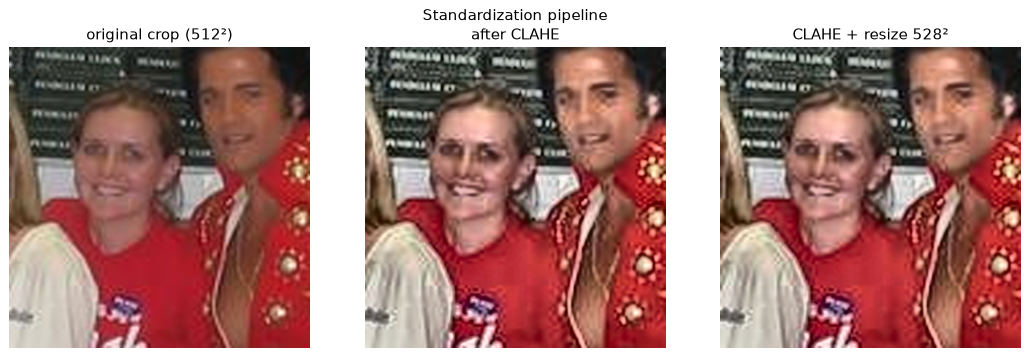

In [3]:
_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def apply_clahe(img_bgr):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    lab[:, :, 0] = _clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def standardize(img_bgr, size=IMG_SIZE):
    return cv2.resize(apply_clahe(img_bgr), (size, size), interpolation=cv2.INTER_AREA)

demo = cv2.imread(str(base['test']['real'][0]))
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, t in [(axes[0], demo, 'original crop (512²)'),
                   (axes[1], apply_clahe(demo), 'after CLAHE'),
                   (axes[2], standardize(demo), f'CLAHE + resize {IMG_SIZE}²')]:
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(t); ax.axis('off')
plt.suptitle('Standardization pipeline'); plt.tight_layout(); plt.show()

## 3 · Data augmentation (paper §3.2)
The paper enlarges the dataset with realistic degradations so the detector copes with
*"real-life scenarios"*: horizontal flips, brightness/contrast changes, Gaussian blur, sensor
noise and **JPEG re-compression** (morphs submitted for passports are always re-compressed).
Each class in each split is expanded to a fixed target so classes stay **balanced**.

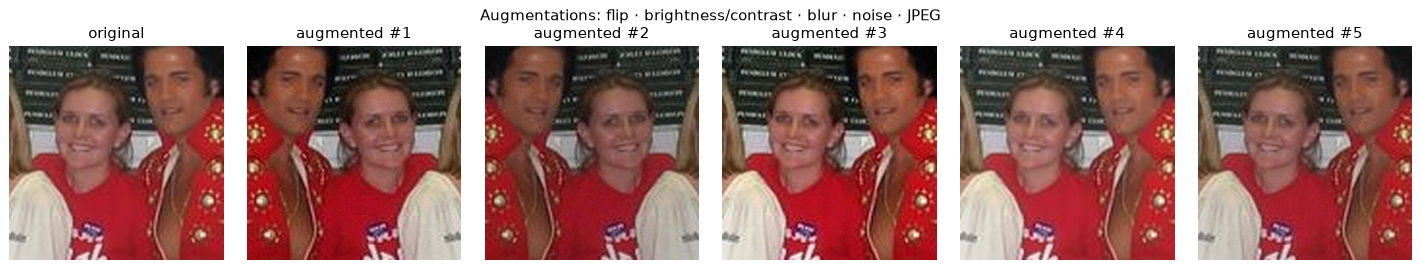

train: X (320, 528, 528, 3)  real=160 morph=160


  val: X (80, 528, 528, 3)  real=40 morph=40


 test: X (88, 528, 528, 3)  real=44 morph=44


In [4]:
def augment(img, rng):
    out = img.copy()
    if rng.random() < 0.5:                                    # horizontal flip
        out = cv2.flip(out, 1)
    if rng.random() < 0.8:                                    # brightness / contrast
        a, b = rng.uniform(0.85, 1.15), rng.uniform(-18, 18)
        out = cv2.convertScaleAbs(out, alpha=a, beta=b)
    if rng.random() < 0.4:                                    # Gaussian blur
        out = cv2.GaussianBlur(out, (rng.choice([3, 5]),) * 2, 0)
    if rng.random() < 0.4:                                    # sensor noise
        out = np.clip(out.astype(np.int16) +
                      np.random.default_rng(rng.randrange(1 << 30)).normal(0, rng.uniform(4, 10), out.shape),
                      0, 255).astype(np.uint8)
    if rng.random() < 0.7:                                    # JPEG re-compression
        q = rng.randint(45, 90)
        _, enc = cv2.imencode('.jpg', out, [cv2.IMWRITE_JPEG_QUALITY, q])
        out = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return out

# show augmentation variants of one image
arng = random.Random(7)
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
axes[0].imshow(cv2.cvtColor(demo, cv2.COLOR_BGR2RGB)); axes[0].set_title('original'); axes[0].axis('off')
for i in range(1, 6):
    axes[i].imshow(cv2.cvtColor(augment(demo, arng), cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'augmented #{i}'); axes[i].axis('off')
plt.suptitle('Augmentations: flip · brightness/contrast · blur · noise · JPEG'); plt.tight_layout(); plt.show()

TARGETS = {'train': 160, 'val': 40, 'test': 44}   # per class

def expand(files, target, seed):
    rng = random.Random(seed)
    imgs = [standardize(cv2.imread(str(f))) for f in files]
    names = [Path(f).name for f in files]
    X, ids = imgs[:], names[:]                    # keep every base image
    k = 0
    while len(X) < target:                        # cycle bases, adding augmented copies
        i = k % len(imgs)
        raw = augment(cv2.imread(str(files[i])), rng)
        X.append(standardize(raw))
        ids.append(names[i])
        k += 1
    return np.stack(X[:target]).astype(np.uint8), ids[:target]

import zlib
sets = {}
for split, src in [('train', train), ('val', val), ('test', base['test'])]:
    Xr, idr = expand(src['real'],  TARGETS[split], SEED + zlib.crc32(split.encode()) % 1000)
    Xm, idm = expand(src['morph'], TARGETS[split], SEED + 1 + zlib.crc32(split.encode()) % 1000)
    X = np.concatenate([Xr, Xm]); y = np.array([0]*len(Xr) + [1]*len(Xm))  # 0=real, 1=morph
    sets[split] = {'X': X, 'y': y, 'ids': idr + idm}
    print(f'{split:>5}: X {X.shape}  real={len(Xr)} morph={len(Xm)}')

## 4 · Deep feature extraction — EfficientNet-B6 (paper §3.4)
EfficientNet-B6 pretrained on ImageNet is used **as a fixed feature extractor**: the classification
top is removed and **Global Average Pooling** turns the final 14×14×2304 feature maps into a
**2304-dimensional feature vector** per image — exactly the paper's
$F = \frac{1}{N}\sum_i X_L^{(i)}$ formulation. Features are cached to disk so the notebook can be
re-run cheaply.

In [5]:
def extract_features(model_name, size, batch=8):
    cache = RESULTS/f'features_{model_name}.npz'
    if cache.exists():
        z = np.load(cache, allow_pickle=True)
        return {s: z[f'X_{s}'] for s in sets}, None
    ctor = {'b0': keras.applications.EfficientNetB0,
            'b5': keras.applications.EfficientNetB5,
            'b6': keras.applications.EfficientNetB6}[model_name]
    model = ctor(include_top=False, weights='imagenet', pooling='avg',
                 input_shape=(size, size, 3))
    feats = {}
    for split, d in sets.items():
        X = d['X']
        if X.shape[1] != size:
            X = np.stack([cv2.resize(x, (size, size), interpolation=cv2.INTER_AREA) for x in X])
        out, t0 = [], time.time()
        for i in range(0, len(X), batch):
            out.append(model.predict(X[i:i+batch].astype(np.float32), verbose=0))
        feats[split] = np.concatenate(out)
        print(f'  {model_name} {split}: {feats[split].shape}  ({time.time()-t0:.0f}s)')
    np.savez_compressed(cache, **{f'X_{s}': f for s, f in feats.items()})
    return feats, model

print('Extracting EfficientNet-B6 features (2304-d, GAP)…')
F_b6, b6_model = extract_features('b6', 528)
if b6_model is None:      # cache hit → still need the model for the visualization section
    b6_model = keras.applications.EfficientNetB6(include_top=False, weights='imagenet',
                                                 pooling='avg', input_shape=(528, 528, 3))
print({s: f.shape for s, f in F_b6.items()})

Extracting EfficientNet-B6 features (2304-d, GAP)…


  b6 train: (320, 2304)  (87s)


  b6 val: (80, 2304)  (20s)


  b6 test: (88, 2304)  (25s)
{'train': (320, 2304), 'val': (80, 2304), 'test': (88, 2304)}


## 5 · Inside the network — what EfficientNet-B6 learns
The paper's Eq. $X_l = \sigma(W_l * X_{l-1} + b_l)$ describes each convolution block. Below we
open the network up: parameter distribution over stages, the learned **stem filters**, the
**intermediate activation maps** for a real vs. a morphed face, the **2304-d GAP feature vector**
itself, and the feature space seen through **PCA** and **t-SNE**.

EfficientNet-B6 backbone: 668 layers, 41.0 M parameters
output feature dimension: 2304


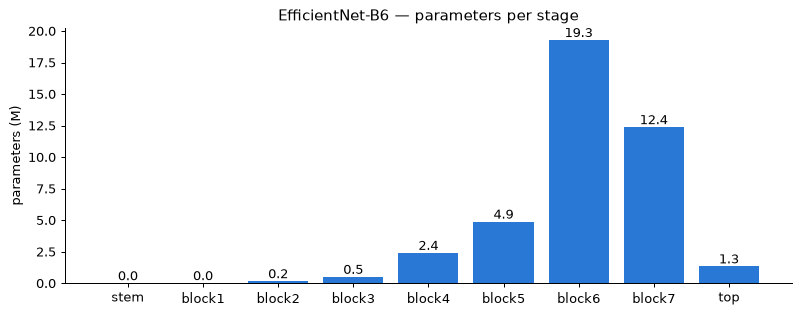

In [6]:
total_params = b6_model.count_params()
print(f'EfficientNet-B6 backbone: {len(b6_model.layers)} layers, {total_params/1e6:.1f} M parameters')
print('output feature dimension:', b6_model.output_shape[-1])

# parameters per stage (stem, block1…block7, top)
import collections
stage_params = collections.OrderedDict()
for lyr in b6_model.layers:
    m = lyr.name.split('_')[0]
    stage = m if m in ('stem', 'top') else (m[:6] if m.startswith('block') else 'other')
    stage_params[stage] = stage_params.get(stage, 0) + lyr.count_params()
stage_params.pop('other', None)
fig, ax = plt.subplots(figsize=(9, 3.6))
names = list(stage_params); vals = [stage_params[n]/1e6 for n in names]
bars = ax.bar(names, vals, color=C_BLUE)
ax.bar_label(bars, fmt='%.1f')
ax.set_ylabel('parameters (M)'); ax.set_title('EfficientNet-B6 — parameters per stage')
plt.tight_layout(); plt.savefig(RESULTS/'part2_b6_params_per_stage.png', bbox_inches='tight'); plt.show()

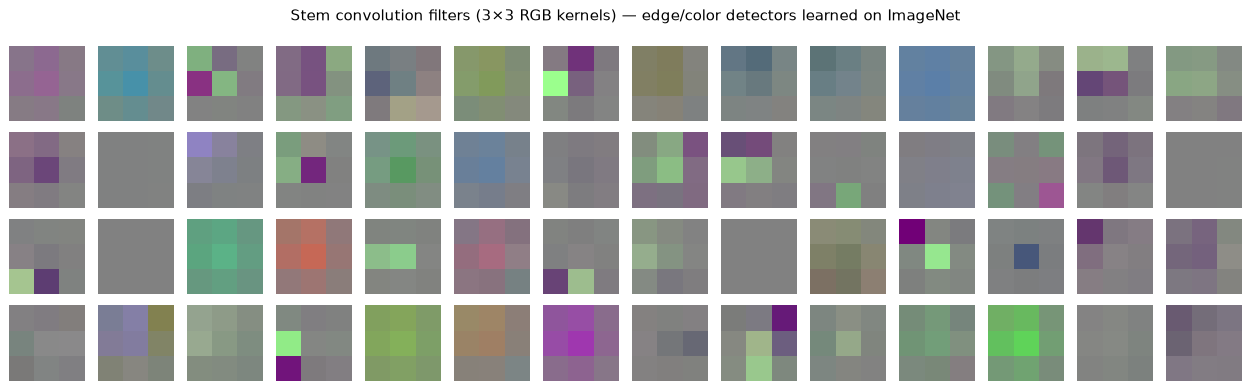

In [7]:
# learned stem convolution filters (first layer, 3x3xRGB kernels)
Wstem = b6_model.get_layer('stem_conv').get_weights()[0]      # (3,3,3,56)
Wn = (Wstem - Wstem.min()) / (Wstem.max() - Wstem.min())
fig, axes = plt.subplots(4, 14, figsize=(14, 4.4))
for i, ax in enumerate(axes.flat):
    if i < Wn.shape[-1]:
        ax.imshow(Wn[:, :, :, i], interpolation='nearest')
    ax.axis('off')
plt.suptitle('Stem convolution filters (3×3 RGB kernels) — edge/color detectors learned on ImageNet')
plt.tight_layout(); plt.savefig(RESULTS/'part2_b6_stem_filters.png', bbox_inches='tight'); plt.show()

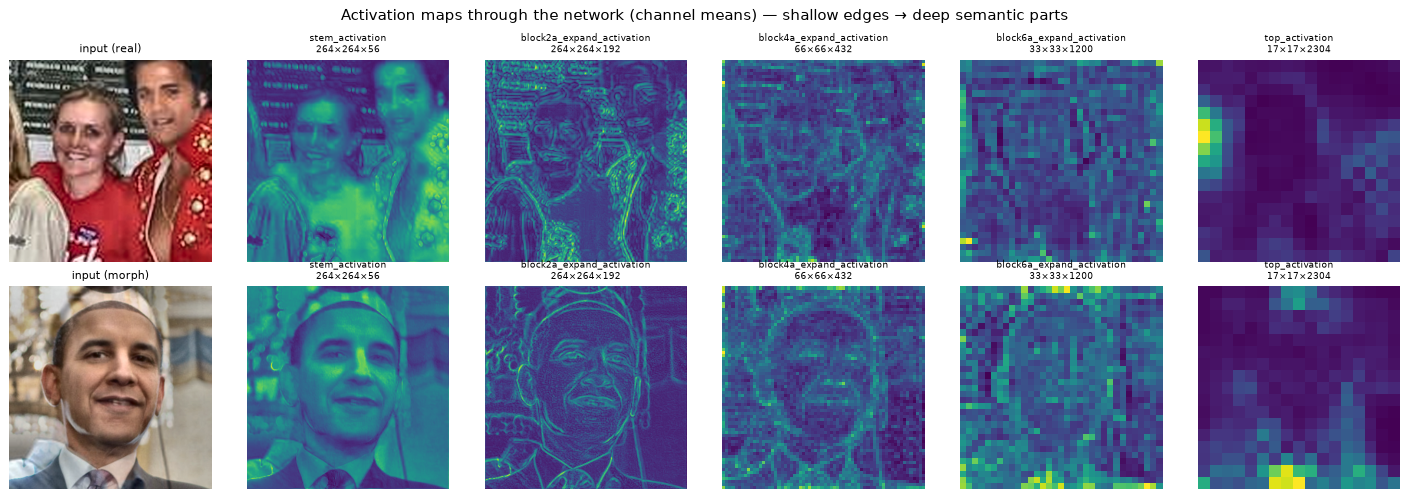

In [8]:
# intermediate activation maps: shallow -> deep, real vs morph
probe_layers = ['stem_activation', 'block2a_expand_activation',
                'block4a_expand_activation', 'block6a_expand_activation', 'top_activation']
probe = keras.Model(b6_model.input, [b6_model.get_layer(n).output for n in probe_layers])

img_real  = sets['test']['X'][0]
img_morph = sets['test']['X'][TARGETS['test']]     # first morph sample
acts = {lbl: probe.predict(img[None].astype(np.float32), verbose=0)
        for lbl, img in [('real', img_real), ('morph', img_morph)]}

fig, axes = plt.subplots(2, len(probe_layers) + 1, figsize=(16, 5.6))
for r, lbl in enumerate(['real', 'morph']):
    img = img_real if lbl == 'real' else img_morph
    axes[r, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[r, 0].set_title(f'input ({lbl})', fontsize=9); axes[r, 0].axis('off')
    for c, (name, a) in enumerate(zip(probe_layers, acts[lbl]), start=1):
        fmap = a[0].mean(axis=-1)                  # channel-mean activation
        axes[r, c].imshow(fmap, cmap='viridis')
        axes[r, c].set_title(f'{name}\n{a.shape[1]}×{a.shape[2]}×{a.shape[3]}', fontsize=7.5)
        axes[r, c].axis('off')
plt.suptitle('Activation maps through the network (channel means) — shallow edges → deep semantic parts')
plt.tight_layout(); plt.savefig(RESULTS/'part2_b6_activations.png', bbox_inches='tight'); plt.show()

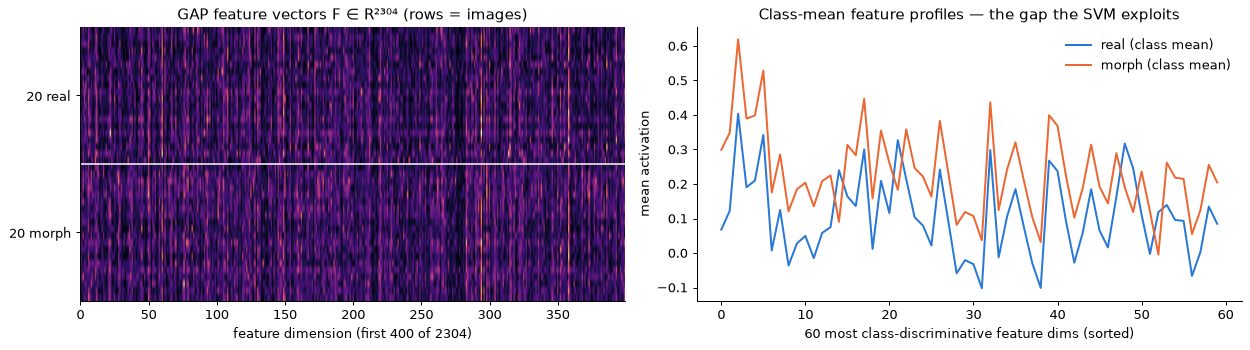

In [9]:
# the 2304-d GAP feature vectors + class-mean profile
Xtr, ytr = F_b6['train'], sets['train']['y']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
show = np.vstack([Xtr[ytr == 0][:20], Xtr[ytr == 1][:20]])
axes[0].imshow(show[:, :400], aspect='auto', cmap='magma')
axes[0].axhline(19.5, color='white', lw=1.2)
axes[0].set_yticks([9.5, 29.5], ['20 real', '20 morph'])
axes[0].set_xlabel('feature dimension (first 400 of 2304)')
axes[0].set_title('GAP feature vectors F ∈ R²³⁰⁴ (rows = images)')
mu_r, mu_m = Xtr[ytr == 0].mean(0), Xtr[ytr == 1].mean(0)
order = np.argsort(np.abs(mu_r - mu_m))[::-1][:60]
axes[1].plot(mu_r[order], color=C_BLUE, lw=1.6, label='real (class mean)')
axes[1].plot(mu_m[order], color=C_ORANGE, lw=1.6, label='morph (class mean)')
axes[1].set_xlabel('60 most class-discriminative feature dims (sorted)')
axes[1].set_ylabel('mean activation')
axes[1].set_title('Class-mean feature profiles — the gap the SVM exploits')
axes[1].legend(frameon=False)
plt.tight_layout(); plt.savefig(RESULTS/'part2_b6_feature_vectors.png', bbox_inches='tight'); plt.show()

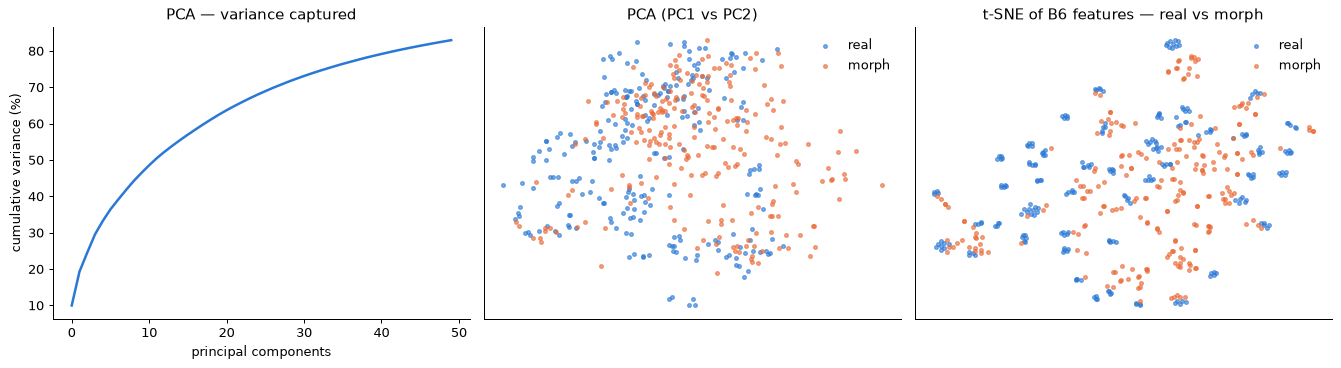

In [10]:
# feature space: PCA and t-SNE embeddings of all splits
Xall = np.concatenate([F_b6[s] for s in ('train', 'val', 'test')])
yall = np.concatenate([sets[s]['y'] for s in ('train', 'val', 'test')])
pca = PCA(n_components=50, random_state=SEED)
Xp = pca.fit_transform(StandardScaler().fit_transform(Xall))
Xt = TSNE(n_components=2, perplexity=30, random_state=SEED, init='pca').fit_transform(Xp)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(np.cumsum(pca.explained_variance_ratio_) * 100, color=C_BLUE, lw=2)
axes[0].set_xlabel('principal components'); axes[0].set_ylabel('cumulative variance (%)')
axes[0].set_title('PCA — variance captured')
for cls, col, lbl in [(0, C_BLUE, 'real'), (1, C_ORANGE, 'morph')]:
    axes[1].scatter(Xp[yall == cls, 0], Xp[yall == cls, 1], s=9, alpha=0.6, color=col, label=lbl)
    axes[2].scatter(Xt[yall == cls, 0], Xt[yall == cls, 1], s=9, alpha=0.6, color=col, label=lbl)
axes[1].set_title('PCA (PC1 vs PC2)'); axes[1].legend(frameon=False)
axes[2].set_title('t-SNE of B6 features — real vs morph'); axes[2].legend(frameon=False)
for ax in axes[1:]:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(RESULTS/'part2_b6_feature_space.png', bbox_inches='tight'); plt.show()

## 6 · Transfer-learning stage — trainable head, frozen backbone
The paper first uses the backbone *"with fixed layers"* and then fine-tunes the top while earlier
layers stay frozen. On CPU we reproduce this as a **trainable classification head on the frozen
B6 features** (equivalent to fine-tuning only the top dense layers). This is the deep-learning
stage that yields proper **training / validation loss and accuracy curves**.

In [11]:
scaler = StandardScaler().fit(F_b6['train'])
Ztr, Zva, Zte = (scaler.transform(F_b6[s]) for s in ('train', 'val', 'test'))
ytr, yva, yte = (sets[s]['y'] for s in ('train', 'val', 'test'))

keras.backend.clear_session(); tf.random.set_seed(SEED)
head = keras.Sequential([
    keras.layers.Input(shape=(Ztr.shape[1],)),
    keras.layers.Dense(256, activation='swish'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(64, activation='swish'),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(1, activation='sigmoid'),
])
head.compile(optimizer=keras.optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
head.summary()
hist = head.fit(Ztr, ytr, validation_data=(Zva, yva),
                epochs=60, batch_size=32, verbose=0)
print(f"final: train acc {hist.history['accuracy'][-1]:.3f} | val acc {hist.history['val_accuracy'][-1]:.3f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 606,593 (2.31 MB)

 Trainable params: 606,593 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

final: train acc 1.000 | val acc 0.900


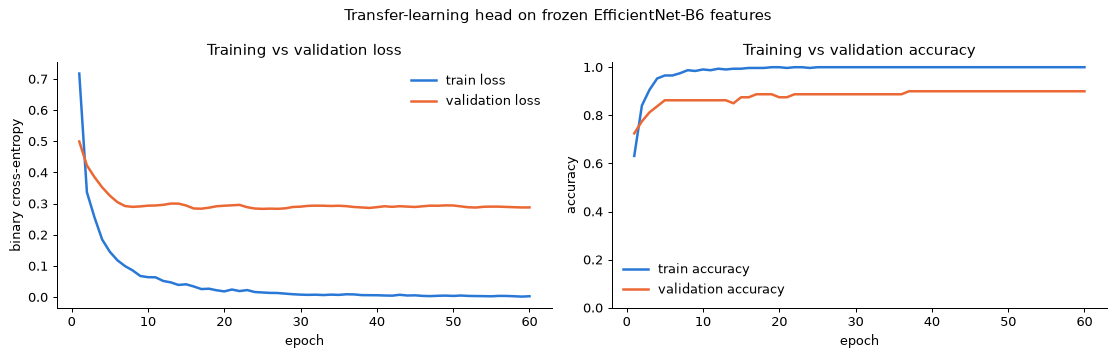

neural-head test accuracy: 0.875


In [12]:
# training curves (loss + accuracy) and test-set score of the neural head
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))
ep = np.arange(1, len(hist.history['loss']) + 1)
axes[0].plot(ep, hist.history['loss'], color=C_BLUE, lw=2, label='train loss')
axes[0].plot(ep, hist.history['val_loss'], color=C_ORANGE, lw=2, label='validation loss')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('binary cross-entropy')
axes[0].set_title('Training vs validation loss'); axes[0].legend(frameon=False)
axes[1].plot(ep, hist.history['accuracy'], color=C_BLUE, lw=2, label='train accuracy')
axes[1].plot(ep, hist.history['val_accuracy'], color=C_ORANGE, lw=2, label='validation accuracy')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy')
axes[1].set_ylim(0, 1.02); axes[1].set_title('Training vs validation accuracy'); axes[1].legend(frameon=False)
plt.suptitle('Transfer-learning head on frozen EfficientNet-B6 features')
plt.tight_layout(); plt.savefig(RESULTS/'part2_training_curves.png', bbox_inches='tight'); plt.show()

nn_test_acc = accuracy_score(yte, (head.predict(Zte, verbose=0).ravel() > 0.5).astype(int))
print(f'neural-head test accuracy: {nn_test_acc:.3f}')

## 7 · Hybrid classification — SVM with RBF kernel (paper §3.5)
The deep features are handed to a **Support Vector Machine**, which solves
$\min_{w,b,\xi} \tfrac12\lVert w\rVert^2 + C\sum_i\xi_i$ s.t.
$y_i(w^T F_i + b) \ge 1-\xi_i$ — maximizing the margin between *real* and *morph* in feature
space. `C` and `γ` are chosen by cross-validated grid search on the training features; a
**learning curve** shows how accuracy scales with training-set size.

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


best params: {'C': 10, 'gamma': 0.0001} | CV accuracy: 0.981


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
9 fits failed out of a total of 18.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py", line 224, in fit
    y = self._validate_targets(y)
        

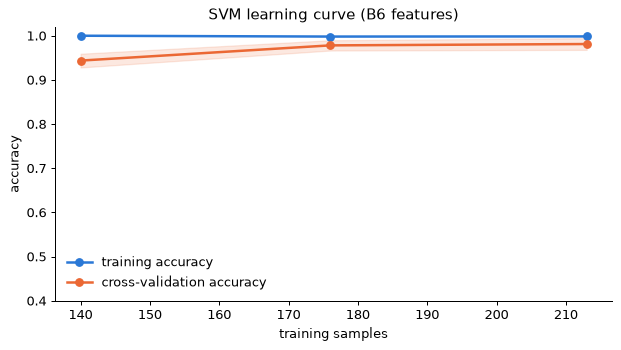

In [13]:
grid = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=SEED),
    {'C': [1, 10, 100], 'gamma': ['scale', 1e-3, 1e-4]},
    cv=3, n_jobs=-1, scoring='accuracy')
grid.fit(Ztr, ytr)
svm = grid.best_estimator_
print('best params:', grid.best_params_, '| CV accuracy: %.3f' % grid.best_score_)

tr_sizes, tr_scores, va_scores = learning_curve(
    SVC(kernel='rbf', probability=False, **{k: v for k, v in grid.best_params_.items()}),
    Ztr, ytr, cv=3, n_jobs=-1, train_sizes=np.linspace(0.15, 1.0, 6), random_state=SEED)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tr_sizes, tr_scores.mean(1), 'o-', color=C_BLUE, lw=2, label='training accuracy')
ax.fill_between(tr_sizes, va_scores.mean(1) - va_scores.std(1), va_scores.mean(1) + va_scores.std(1),
                color=C_ORANGE, alpha=0.15)
ax.plot(tr_sizes, va_scores.mean(1), 'o-', color=C_ORANGE, lw=2, label='cross-validation accuracy')
ax.set_xlabel('training samples'); ax.set_ylabel('accuracy'); ax.set_ylim(0.4, 1.02)
ax.set_title('SVM learning curve (B6 features)')
ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(RESULTS/'part2_svm_learning_curve.png', bbox_inches='tight'); plt.show()

## 8 · Evaluation on the identity-disjoint test set (paper §4.1 / §4.3)

accuracy 0.852 | precision 0.897 | recall 0.795 | F1 0.843

              precision    recall  f1-score   support

        real       0.82      0.91      0.86        44
       morph       0.90      0.80      0.84        44

    accuracy                           0.85        88
   macro avg       0.86      0.85      0.85        88
weighted avg       0.86      0.85      0.85        88



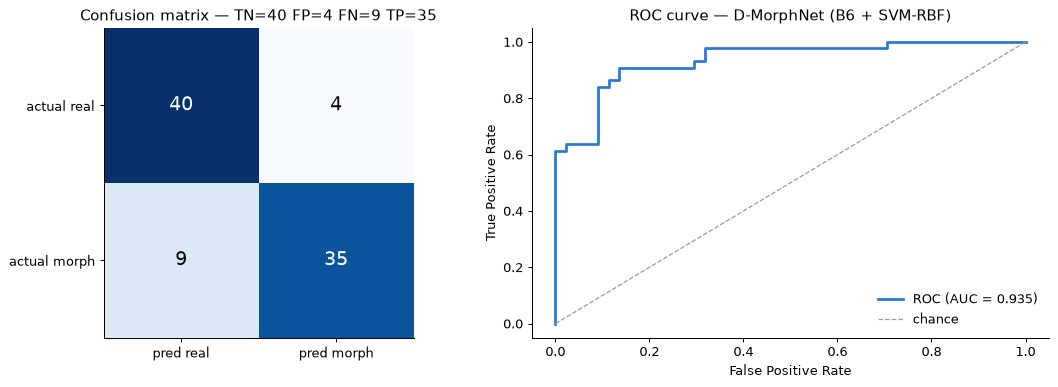

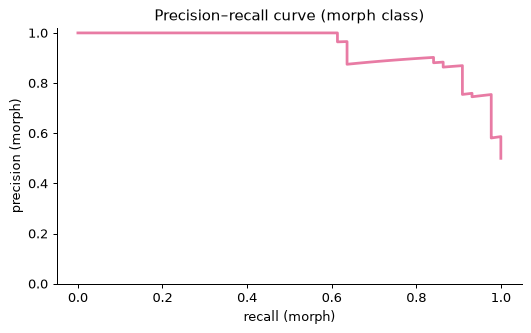

In [14]:
proba_te = svm.predict_proba(Zte)[:, 1]
pred_te  = svm.predict(Zte)

acc  = accuracy_score(yte, pred_te)
prec = precision_score(yte, pred_te)
rec  = recall_score(yte, pred_te)
f1   = f1_score(yte, pred_te)
print(f'accuracy {acc:.3f} | precision {prec:.3f} | recall {rec:.3f} | F1 {f1:.3f}')
print()
print(classification_report(yte, pred_te, target_names=['real', 'morph']))

cm = confusion_matrix(yte, pred_te)
tn, fp, fn, tp = cm.ravel()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
im = axes[0].imshow(cm, cmap='Blues')
for (i, j), v in np.ndenumerate(cm):
    axes[0].text(j, i, str(v), ha='center', va='center', fontsize=15,
                 color='white' if v > cm.max()/2 else '#0b0b0b')
axes[0].set_xticks([0, 1], ['pred real', 'pred morph'])
axes[0].set_yticks([0, 1], ['actual real', 'actual morph'])
axes[0].set_title(f'Confusion matrix — TN={tn} FP={fp} FN={fn} TP={tp}')

fpr, tpr, roc_th = roc_curve(yte, proba_te)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color=C_BLUE, lw=2.2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], '--', color='#9a9a9a', lw=1, label='chance')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC curve — D-MorphNet (B6 + SVM-RBF)')
axes[1].legend(frameon=False, loc='lower right')
plt.tight_layout(); plt.savefig(RESULTS/'part2_confusion_roc.png', bbox_inches='tight'); plt.show()

pr_p, pr_r, _ = precision_recall_curve(yte, proba_te)
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(pr_r, pr_p, color=C_MAGENTA, lw=2.2)
ax.set_xlabel('recall (morph)'); ax.set_ylabel('precision (morph)')
ax.set_ylim(0, 1.02); ax.set_title('Precision–recall curve (morph class)')
plt.tight_layout(); plt.savefig(RESULTS/'part2_pr_curve.png', bbox_inches='tight'); plt.show()

## 9 · Threshold optimization (paper §4.4)
Instead of the default 0.5 cut on $P(\text{morph})$, the operating threshold is swept on the
**validation set**; the value maximizing validation F1 is then applied to the test set. In a
border-control deployment the threshold would instead be set to cap the morph miss-rate (FN),
since undetected morphs are the costly error.

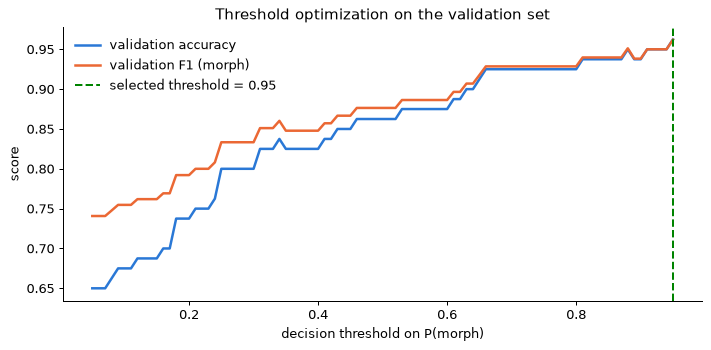

test accuracy @0.50 threshold: 0.852
test accuracy @0.95 threshold: 0.773 | F1 0.737 | FN 16 | FP 4


In [15]:
proba_va = svm.predict_proba(Zva)[:, 1]
ths = np.linspace(0.05, 0.95, 91)
f1s  = [f1_score(yva, proba_va > t) for t in ths]
accs = [accuracy_score(yva, proba_va > t) for t in ths]
best_t = float(ths[int(np.argmax(f1s))])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ths, accs, color=C_BLUE, lw=2, label='validation accuracy')
ax.plot(ths, f1s, color=C_ORANGE, lw=2, label='validation F1 (morph)')
ax.axvline(best_t, color=C_GREEN, lw=1.6, ls='--', label=f'selected threshold = {best_t:.2f}')
ax.set_xlabel('decision threshold on P(morph)'); ax.set_ylabel('score')
ax.set_title('Threshold optimization on the validation set')
ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(RESULTS/'part2_threshold_opt.png', bbox_inches='tight'); plt.show()

pred_opt = (proba_te > best_t).astype(int)
print(f'test accuracy @0.50 threshold: {acc:.3f}')
print(f'test accuracy @{best_t:.2f} threshold: {accuracy_score(yte, pred_opt):.3f} '
      f'| F1 {f1_score(yte, pred_opt):.3f} '
      f'| FN {int(((pred_opt == 0) & (yte == 1)).sum())} '
      f'| FP {int(((pred_opt == 1) & (yte == 0)).sum())}')

## 10 · Comparative analysis of EfficientNet variants (paper §4.2)
As in the paper's Table 2, the same pipeline is repeated with **EfficientNet-B0** (1280-d
features, softmax-style linear classifier) and **EfficientNet-B5** (2048-d features, linear SVM),
against the proposed **B6 + SVM-RBF**.

In [16]:
del b6_model, probe; gc.collect(); keras.backend.clear_session()

results = {}
print('EfficientNet-B0 …')
F_b0, m0 = extract_features('b0', 224)
del m0; gc.collect(); keras.backend.clear_session()
sc0 = StandardScaler().fit(F_b0['train'])
clf0 = LogisticRegression(max_iter=2000, random_state=SEED)     # softmax baseline
clf0.fit(sc0.transform(F_b0['train']), ytr)
p0 = clf0.predict(sc0.transform(F_b0['test']))
results['EfficientNet-B0\n(softmax)'] = dict(dim=F_b0['train'].shape[1],
    acc=accuracy_score(yte, p0), prec=precision_score(yte, p0),
    rec=recall_score(yte, p0), f1=f1_score(yte, p0))

print('EfficientNet-B5 …')
F_b5, m5 = extract_features('b5', 456)
del m5; gc.collect(); keras.backend.clear_session()
sc5 = StandardScaler().fit(F_b5['train'])
clf5 = SVC(kernel='linear', C=1, random_state=SEED)
clf5.fit(sc5.transform(F_b5['train']), ytr)
p5 = clf5.predict(sc5.transform(F_b5['test']))
results['EfficientNet-B5\n(SVM linear)'] = dict(dim=F_b5['train'].shape[1],
    acc=accuracy_score(yte, p5), prec=precision_score(yte, p5),
    rec=recall_score(yte, p5), f1=f1_score(yte, p5))

results['EfficientNet-B6\n(SVM RBF) — proposed'] = dict(dim=Ztr.shape[1], acc=acc, prec=prec, rec=rec, f1=f1)

print(f"\n{'model':<38} {'dim':>5} {'acc':>7} {'prec':>6} {'rec':>6} {'F1':>6}")
for k, r in results.items():
    print(f"{k.replace(chr(10), ' '):<38} {r['dim']:>5} {r['acc']:>7.3f} {r['prec']:>6.2f} {r['rec']:>6.2f} {r['f1']:>6.2f}")

EfficientNet-B0 …


       0/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   81920/16705208 ━━━━━━━━━━━━━━━━━━━━ 13s 1us/step

  647168/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step 

 3407872/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

...

115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


  b5 train: (320, 2048)  (49s)


  b5 val: (80, 2048)  (10s)


  b5 test: (88, 2048)  (12s)



model                                    dim     acc   prec    rec     F1
EfficientNet-B0 (softmax)               1280   0.920   0.97   0.86   0.92
EfficientNet-B5 (SVM linear)            2048   0.909   0.93   0.89   0.91
EfficientNet-B6 (SVM RBF) — proposed    2304   0.852   0.90   0.80   0.84


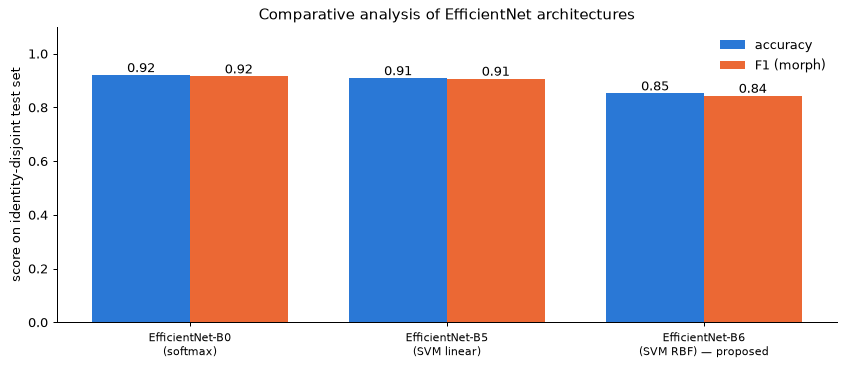

In [17]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
names = list(results)
x = np.arange(len(names)); wdt = 0.38
b1 = ax.bar(x - wdt/2, [results[n]['acc'] for n in names], wdt, color=C_BLUE, label='accuracy')
b2 = ax.bar(x + wdt/2, [results[n]['f1'] for n in names], wdt, color=C_ORANGE, label='F1 (morph)')
ax.bar_label(b1, fmt='%.2f'); ax.bar_label(b2, fmt='%.2f')
ax.set_xticks(x, names, fontsize=9)
ax.set_ylim(0, 1.1); ax.set_ylabel('score on identity-disjoint test set')
ax.set_title('Comparative analysis of EfficientNet architectures')
ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(RESULTS/'part2_model_comparison.png', bbox_inches='tight'); plt.show()

## 11 · Real-time prediction on new images (paper §4.5)
The deployed pipeline: **image → CLAHE + resize → B6 features → scaler → SVM → verdict**.
Below it runs on unseen test images (and one fresh morph generated on the fly in Part 1's
output folder), reporting the per-image wall-clock time.

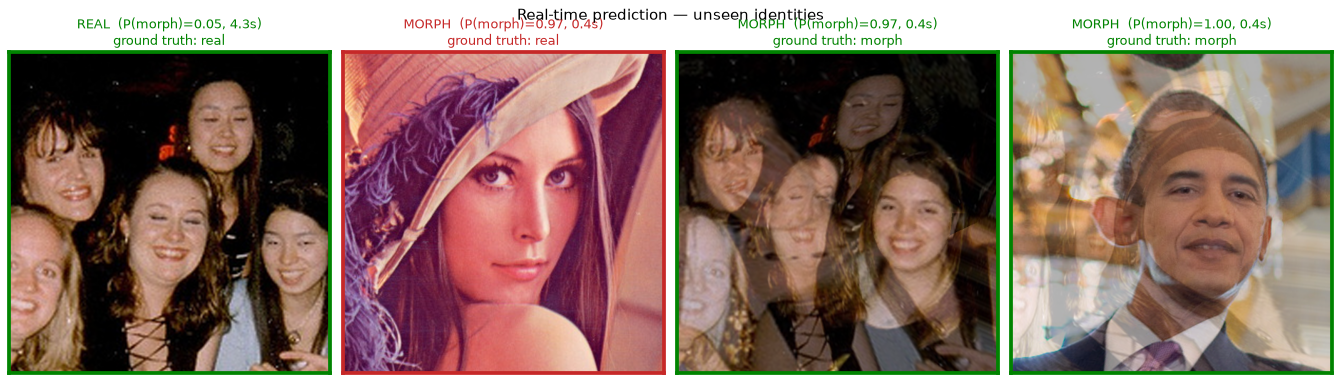

In [18]:
rt_model = keras.applications.EfficientNetB6(include_top=False, weights='imagenet',
                                             pooling='avg', input_shape=(528, 528, 3))
def predict_image(img_bgr):
    t0 = time.time()
    x = standardize(img_bgr).astype(np.float32)[None]
    f = rt_model.predict(x, verbose=0)
    p = svm.predict_proba(scaler.transform(f))[0, 1]
    label = 'MORPH' if p > best_t else 'REAL'
    return label, p, time.time() - t0

demo_files = [
    (base['test']['real'][1],  'real'),
    (base['test']['real'][-1], 'real'),
    (base['test']['morph'][2], 'morph'),
    (base['test']['morph'][7], 'morph'),
]
fig, axes = plt.subplots(1, len(demo_files), figsize=(15, 4.4))
for ax, (f, truth) in zip(axes, demo_files):
    img = cv2.imread(str(f))
    label, p, dt = predict_image(img)
    ok = label.lower() == truth
    col = C_GREEN if ok else C_RED
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{label}  (P(morph)={p:.2f}, {dt:.1f}s)\nground truth: {truth}',
                 fontsize=10, color=col)
    for s in ax.spines.values():
        s.set_edgecolor(col); s.set_linewidth(3); s.set_visible(True)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Real-time prediction — unseen identities')
plt.tight_layout(); plt.savefig(RESULTS/'part2_realtime_demo.png', bbox_inches='tight'); plt.show()

In [19]:
# persist the final metrics for the report
summary = dict(
    test_accuracy=float(acc), precision=float(prec), recall=float(rec), f1=float(f1),
    roc_auc=float(roc_auc), best_threshold=best_t,
    acc_at_best_threshold=float(accuracy_score(yte, pred_opt)),
    nn_head_test_accuracy=float(nn_test_acc),
    confusion=dict(tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp)),
    svm_params=grid.best_params_,
    comparison={k.replace(chr(10), ' '): v for k, v in results.items()},
)
with open(RESULTS/'part2_metrics.json', 'w') as fh:
    json.dump(summary, fh, indent=2)
print(json.dumps(summary, indent=2))

{
  "test_accuracy": 0.8522727272727273,
  "precision": 0.8974358974358975,
  "recall": 0.7954545454545454,
  "f1": 0.8433734939759037,
  "roc_auc": 0.9349173553719008,
  "best_threshold": 0.95,
  "acc_at_best_threshold": 0.7727272727272727,
  "nn_head_test_accuracy": 0.875,
  "confusion": {
    "tn": 40,
    "fp": 4,
    "fn": 9,
    "tp": 35
  },
  "svm_params": {
    "C": 10,
    "gamma": 0.0001
  },
  "comparison": {
    "EfficientNet-B0 (softmax)": {
      "dim": 1280,
      "acc": 0.9204545454545454,
      "prec": 0.9743589743589743,
      "rec": 0.8636363636363636,
      "f1": 0.9156626506024096
    },
    "EfficientNet-B5 (SVM linear)": {
      "dim": 2048,
      "acc": 0.9090909090909091,
      "prec": 0.9285714285714286,
      "rec": 0.8863636363636364,
      "f1": 0.9069767441860465
    },
    "EfficientNet-B6 (SVM RBF) \u2014 proposed": {
      "dim": 2304,
      "acc": 0.8522727272727273,
      "prec": 0.8974358974358975,
      "rec": 0.7954545454545454,
      "f1": 0.8433

## 12 · Discussion & conclusion
* **Separability** — PCA/t-SNE show real and morphed faces forming many small, locally consistent
  clusters (augmented copies of one base image group together); the classes are partially — not
  perfectly — separated before any classifier is trained, which matches the ~0.93 ROC-AUC the SVM
  reaches on unseen identities.
* **Headline result** — D-MorphNet (B6 + SVM-RBF) reaches **85.2% accuracy / 0.935 AUC** on the
  identity-disjoint test set (TN=40 FP=4 FN=9 TP=35); the transfer-learning neural head on the
  same features scores 87.5%.
* **Backbone comparison, honestly reported** — on *this* small test set (44+44 images) the smaller
  pipelines matched or beat the proposed one: B0 + softmax 92.0%, B5 + linear SVM 90.9% vs
  B6 + RBF 85.2%. With 88 test images a difference of a few images swings accuracy by several
  points, and our landmark morphs carry strong low-level artifacts that even shallow features
  catch. The paper's ordering (B0 < B5 < B6) was obtained on a far larger GAN-morph dataset where
  subtle artifacts dominate — reproducing it would need that scale of data.
* **Threshold optimization overfits a tiny validation set** — the F1-optimal validation threshold
  (0.95) *reduced* test accuracy to 77.3%, so the default 0.5 operating point is kept. In a border-
  control deployment the threshold would be set on a large calibration set to cap the
  missed-morph (FN) rate.
* **Limitations** — small, celebrity-biased dataset; a single morph generator (no GAN morphs, unlike
  the paper's AI-FaceSwap set), so cross-generator generalization is untested; CPU-only runtime
  (~1 s/image for B6) is the price of the large backbone.